In [1]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = r"C:\Users\LOQ\Downloads\smart meter\hhblock_dataset"
meter_id = "MAC000002"
all_files = glob.glob(os.path.join(path, "block_*.csv"))
print("Total files found:", len(all_files))

Total files found: 112


In [3]:
dfs = []
for file in all_files:
    df = pd.read_csv(file)
    df = df[df["LCLid"] == meter_id]
    if not df.empty:
        dfs.append(df)

In [4]:
df_meter = pd.concat(dfs, ignore_index=True)
print("Rows for selected meter:", len(df_meter))

Rows for selected meter: 498


In [5]:
# convert date
#df_meter['day'] = pd.to_datetime(df_meter['day'], format='%Y-%m-%d', errors='coerce')
df_meter['day'] = pd.to_datetime(df_meter['day'], errors='coerce')

In [6]:
df_meter.head()

,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256


In [7]:
# Melt hh_0 … hh_47 into long format
df_long = df_meter.melt(
    id_vars=['LCLid', 'day'],
    value_vars=[f"hh_{i}" for i in range(48)],
    var_name='half_hour',
    value_name='energy'
)

In [8]:
# Extract numeric half-hour index (0–47)
df_long['half_hour'] = df_long['half_hour'].str.extract('(\d+)').astype(int)

In [9]:
# Combine date + half-hour index into datetime
df_long['datetime'] = df_long['day'] + pd.to_timedelta(df_long['half_hour'] * 30, unit='m')
df_long = df_long.sort_values('datetime').reset_index(drop=True)

# Final time series
df_long = df_long[['datetime', 'energy']].set_index('datetime')
df_long.head(10)

,energy
datetime,
2012-10-13 00:00:00,0.263
2012-10-13 00:30:00,0.269
2012-10-13 01:00:00,0.275
2012-10-13 01:30:00,0.256
2012-10-13 02:00:00,0.211
2012-10-13 02:30:00,0.136
2012-10-13 03:00:00,0.161
2012-10-13 03:30:00,0.119
2012-10-13 04:00:00,0.167


In [10]:
# Enforce 30-minute frequency
df_long = df_long.asfreq('30min')   # use 'min' instead of deprecated 'T'

# Show info and missing stats
print(df_long.info())
print("Missing values:", df_long['energy'].isna().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24144 entries, 2012-10-13 00:00:00 to 2014-02-27 23:30:00
Freq: 30min
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   energy  23903 non-null  float64
dtypes: float64(1)
memory usage: 377.2 KB
None
Missing values: 241


In [11]:
df_long['energy'] = df_long['energy'].fillna(
    df_long['energy'].rolling('7D', min_periods=1).mean()
)

In [12]:
print("Missing values:", df_long['energy'].isna().sum())

Missing values: 0


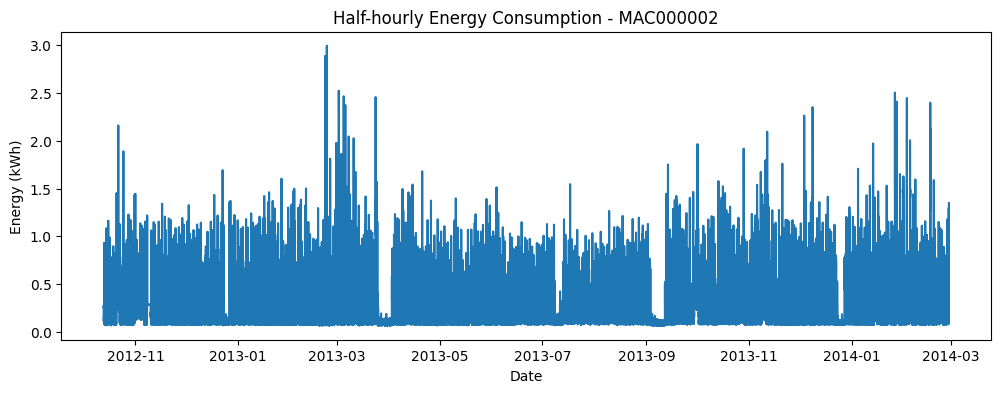

In [13]:
plt.figure(figsize=(12,4))
plt.plot(df_long['energy'])
plt.title(f"Half-hourly Energy Consumption - {meter_id}")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.show()

In [14]:
# resampling
df_hourly = df_long.resample('h').sum()   # hourly
df_daily = df_long.resample('D').sum()    # daily

In [15]:
# train-test split
train_size = int(len(df_long) * 0.8)
train, test = df_long.iloc[:train_size], df_long.iloc[train_size:]

In [16]:
print(len(train)) # TRAIN-SIZE

19315


In [17]:
print(len(test)) # TEST-SIZE

4829


=============================================================================================================

=============================================================================================================

## Models training

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

In [19]:
# Metrics
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'R2': r2}

In [20]:
# plot actual vs predicted
def plot_forecast(index, y_true, y_pred, title="Forecast vs Actual"):
    plt.figure(figsize=(12,4))
    plt.plot(index, y_true, label='Actual')
    plt.plot(index, y_pred, label='Predicted')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Residual diagnostics (hist + ACF)
def residual_diagnostics(residuals, title="Residuals"):
    plt.figure(figsize=(10,3))
    sns.histplot(residuals, kde=True)
    plt.title(f"{title} - Distribution")
    plt.show()
    max_lags = min(40, len(residuals)//2)
    if max_lags >= 2:
        plt.figure(figsize=(10,3))
        plot_acf(residuals, lags=max_lags, zero=False)
        plt.title(f"{title} - ACF")
        plt.show()
    else:
        print("Not enough residuals for ACF plot.")

In [21]:
# Sequence builder for LSTM
def create_sequences(values, window_size):
    X, y = [], []
    for i in range(window_size, len(values)):
        X.append(values[i-window_size:i])
        y.append(values[i])
    X = np.array(X)
    y = np.array(y)
    return X, y

In [22]:
def make_lag_features(series, nlags=24):
    df = pd.DataFrame(series).copy()
    df.columns = ['y']
    for i in range(1, nlags+1):
        df[f'lag_{i}'] = df['y'].shift(i)
    df = df.dropna()
    X = df.drop('y', axis=1).values
    y = df['y'].values
    return X, y, df.index

=============================================================================================================

### ARIMA/SARIMA

In [23]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

series_choice = 'hourly'   # 'hourly' or 'daily'

if series_choice == 'hourly':
    series = df_hourly['energy'].copy()
else:
    series = df_daily['energy'].copy()

# Train/test split (80/20 time-based)
train_size = int(len(series) * 0.8)
train_series = series.iloc[:train_size]
test_series  = series.iloc[train_size:]

print(f"Series length: {len(series)}, Train: {len(train_series)}, Test: {len(test_series)}")

Series length: 12072, Train: 9657, Test: 2415


In [24]:
# Auto ARIMA to find order
print("Running auto_arima (may take some time)...")
auto_model = auto_arima(train_series, seasonal=False, stepwise=True, suppress_warnings=True,
                        max_p=5, max_q=5, max_d=2, error_action='ignore', trace=False)
print("Selected order:", auto_model.order)

Running auto_arima (may take some time)...
Selected order: (2, 1, 5)


In [25]:
# final ARIMA (statsmodels) for full control
p,d,q = auto_model.order
arima = ARIMA(train_series, order=(p,d,q)).fit()
print(arima.summary())

                               SARIMAX Results                                
Dep. Variable:                 energy   No. Observations:                 9657
Model:                 ARIMA(2, 1, 5)   Log Likelihood               -3068.835
Date:                Wed, 29 Oct 2025   AIC                           6153.671
Time:                        01:01:31   BIC                           6211.073
Sample:                    10-13-2012   HQIC                          6173.135
                         - 11-19-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4879      0.030    -16.066      0.000      -0.547      -0.428
ar.L2          0.4948      0.030     16.358      0.000       0.436       0.554
ma.L1          0.0249      0.031      0.813      0.4

In [26]:
# Forecast on test period (dynamic=False ensures one-step forecasts)
start = test_series.index[0]
end = test_series.index[-1]
arima_forecast = arima.predict(start=start, end=end, dynamic=False)

In [27]:
# Align lengths (some auto_arima/statsmodels indexing quirks)
arima_forecast = arima_forecast.reindex(test_series.index)

# Evaluate
metrics = evaluate(test_series.values, arima_forecast.values)
print("ARIMA metrics:", metrics)

ARIMA metrics: {'MSE': 0.26453824004703547, 'RMSE': 0.5143328105876928, 'MAE': 0.35255819907880726, 'MAPE (%)': 86.19778861972443, 'R2': -0.0061742823311015105}


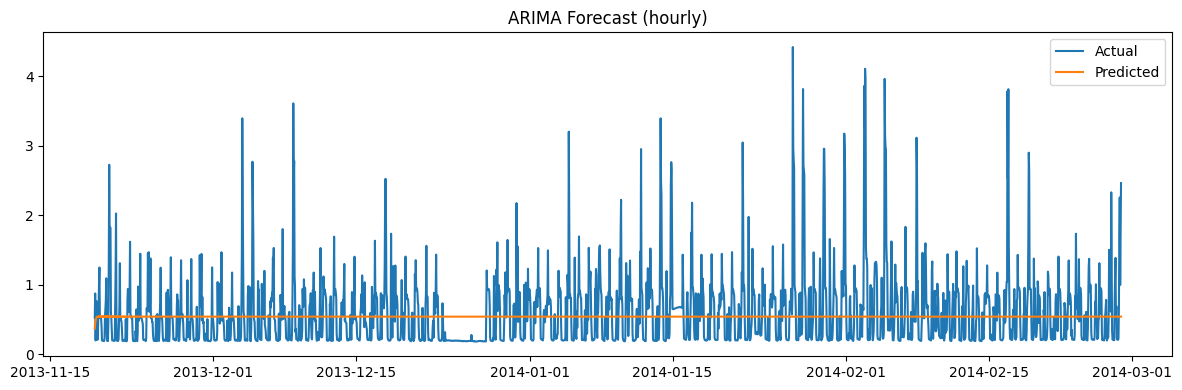

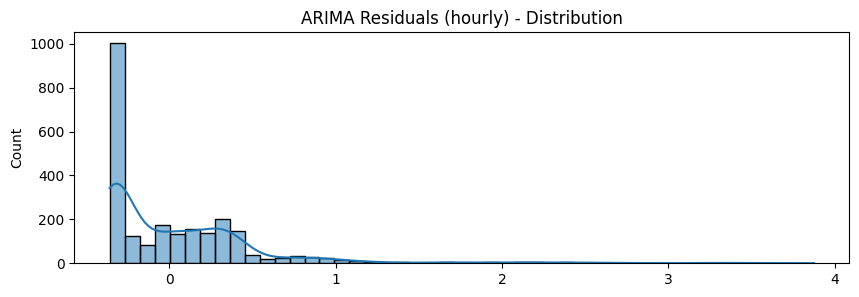

<Figure size 1000x300 with 0 Axes>

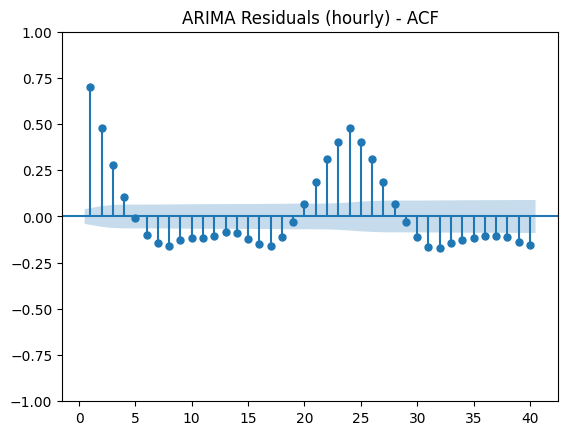

In [29]:
import seaborn as sns

plot_forecast(test_series.index, test_series.values, arima_forecast.values, title=f"ARIMA Forecast ({series_choice})")
residuals = test_series.values - arima_forecast.values
residual_diagnostics(residuals, title=f"ARIMA Residuals ({series_choice})")

=============================================================================================================

### Prophet

In [30]:
from prophet import Prophet

series_choice = 'hourly'  # 'hourly' or 'daily'

if series_choice == 'hourly':
    s = df_hourly['energy'].reset_index().rename(columns={'datetime':'ds','energy':'y'})
else:
    s = df_daily['energy'].reset_index().rename(columns={'datetime':'ds','energy':'y'})

# train/test split by index position
train_size = int(len(s) * 0.8)
train_df = s.iloc[:train_size].copy()
test_df  = s.iloc[train_size:].copy()

In [31]:
model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
model.fit(train_df)

01:03:08 - cmdstanpy - INFO - Chain [1] start processing
01:03:10 - cmdstanpy - INFO - Chain [1] done processing


In [32]:
# Forecast on test timestamps
future = test_df[['ds']].copy()
forecast = model.predict(future)
y_pred = forecast['yhat'].values
y_true = test_df['y'].values

In [33]:
metrics = evaluate(y_true, y_pred)
print("Prophet metrics:", metrics)

Prophet metrics: {'MSE': 0.24225923544681546, 'RMSE': 0.4921983700164147, 'MAE': 0.3850706093868865, 'MAPE (%)': 118.6301238207521, 'R2': 0.07856417159031248}


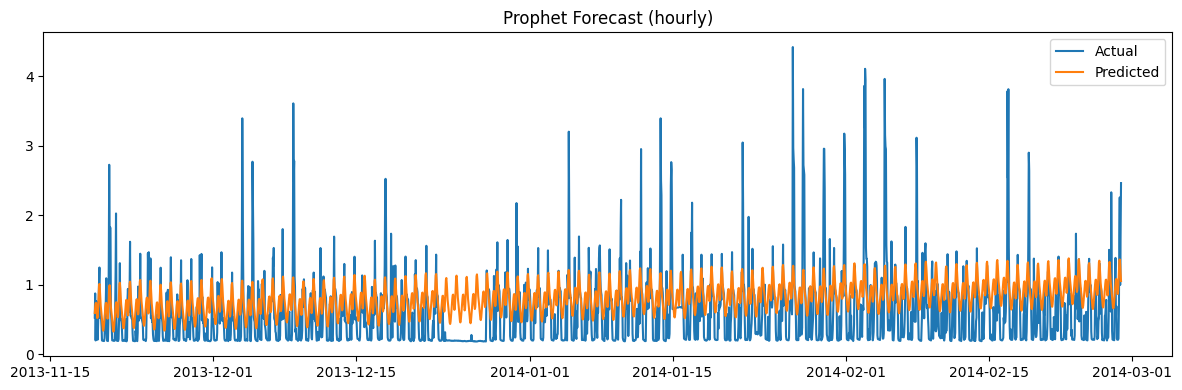

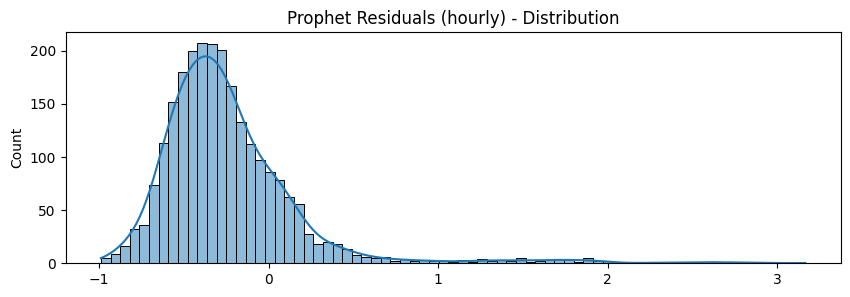

<Figure size 1000x300 with 0 Axes>

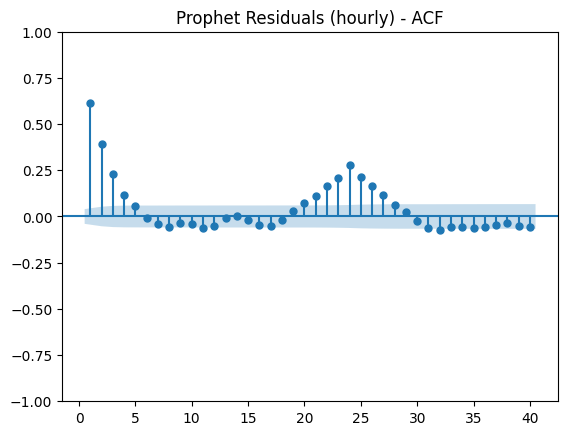

In [34]:
plot_forecast(test_df['ds'], y_true, y_pred, title=f"Prophet Forecast ({series_choice})")
residuals = y_true - y_pred
residual_diagnostics(residuals, title=f"Prophet Residuals ({series_choice})")

=============================================================================================================

### XGBoost

In [35]:
series_choice = 'hourly'  # 'hourly' or 'daily'
nlags = 48 if series_choice=='hourly' else 30   # adjust lags

series = df_hourly['energy'] if series_choice=='hourly' else df_daily['energy']

In [36]:
# lag features
X, y, idx = make_lag_features(series, nlags=nlags)

# Split (based on index)
split = int(len(X)*0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test   = X[split:], y[split:]
idx_test = idx[split:]

In [37]:
# training XGBoost
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [38]:
y_pred = xgb.predict(X_test)

metrics = evaluate(y_test, y_pred)
print("XGBoost metrics:", metrics)

XGBoost metrics: {'MSE': 0.10557690292982325, 'RMSE': 0.32492599608191286, 'MAE': 0.18545229704083654, 'MAPE (%)': 35.68225998568577, 'R2': 0.5997063980649093}


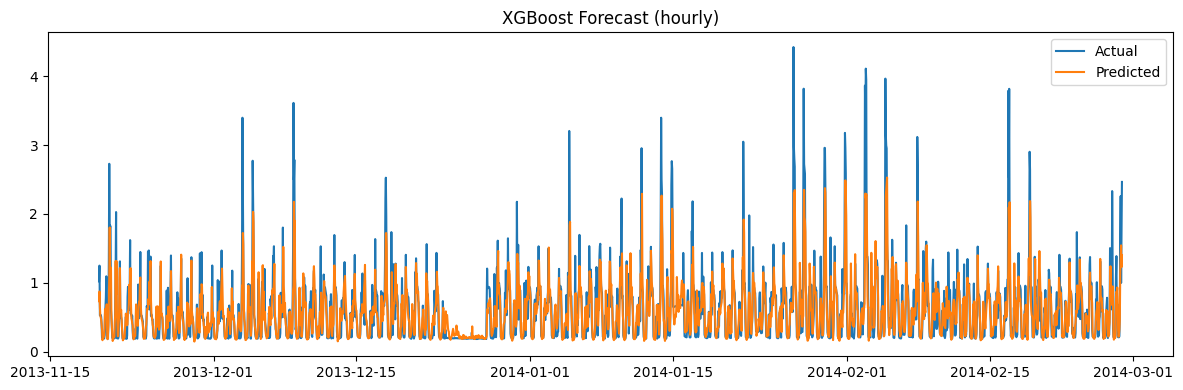

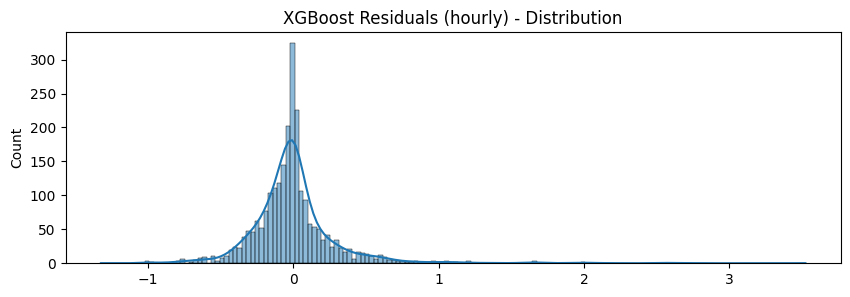

<Figure size 1000x300 with 0 Axes>

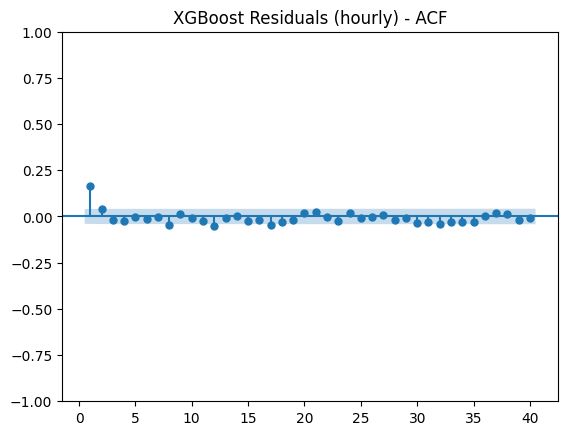

In [39]:
plot_forecast(idx_test, y_test, y_pred, title=f"XGBoost Forecast ({series_choice})")
residuals = y_test - y_pred
residual_diagnostics(residuals, title=f"XGBoost Residuals ({series_choice})")

=============================================================================================================

### LSTM (sequence-based)

In [40]:
# LSTM block
series_choice = 'hourly'  # 'hourly' or 'daily'
window = 48 if series_choice=='hourly' else 30

series = df_hourly['energy'] if series_choice=='hourly' else df_daily['energy']

In [41]:
# scale
scaler = MinMaxScaler()
scaled = scaler.fit_transform(series.values.reshape(-1,1))

In [42]:
# split
train_size = int(len(scaled)*0.8)
train_scaled = scaled[:train_size]
test_scaled  = scaled[train_size:]

In [43]:
# create sequences
X_train, y_train = create_sequences(train_scaled.flatten(), window)
X_test, y_test   = create_sequences(test_scaled.flatten(), window)

In [44]:
# reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [45]:
# build model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window,1)),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.1, epochs=10, batch_size=64, callbacks=[es], verbose=1)



Epoch 1/15

136/136 [==============================] - 6s 25ms/step - loss: 0.0074 - val_loss: 0.0109
Epoch 2/15
136/136 [==============================] - 3s 21ms/step - loss: 0.0062 - val_loss: 0.0099
Epoch 3/15
136/136 [==============================] - 3s 22ms/step - loss: 0.0057 - val_loss: 0.0084
Epoch 4/15
136/136 [==============================] - 3s 22ms/step - loss: 0.0054 - val_loss: 0.0079
Epoch 5/15
136/136 [==============================] - 3s 22ms/step - loss: 0.0053 - val_loss: 0.0078
Epoch 6/15
136/136 [==============================] - 3s 23ms/step - loss: 0.0053 - val_loss: 0.0079
Epoch 7/15
136/136 [==============================] - 3s 21ms/step - loss: 0.0051 - val_loss: 0.0074
Epoch 8/15
136/136 [==============================] - 3s 22ms/step - loss: 0.0051 - val_loss: 0.0076
Epoch 9/15
136/136 [==============================] - 3s 20ms/step - loss: 0.0050 - val_loss: 0.0075
Epoch 10/15
136/136 [==============================] - 3s 21ms/step - loss: 0.0049 - val

In [46]:
# predict and inverse scale
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
# true values (inverse)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

74/74 [==============================] - 1s 6ms/step


In [47]:
metrics = evaluate(y_test_inv, y_pred)
print("LSTM metrics:", metrics)

LSTM metrics: {'MSE': 0.13062829614727317, 'RMSE': 0.36142536732674585, 'MAE': 0.22740489921128249, 'MAPE (%)': 46.03515052659155, 'R2': 0.5022117783837813}


In [48]:
# index for plotting: align with original series index
# compute starting index for test predictions
full_index = series.index
start_pos = train_size + window
idx_pred = full_index[start_pos : start_pos + len(y_pred)]

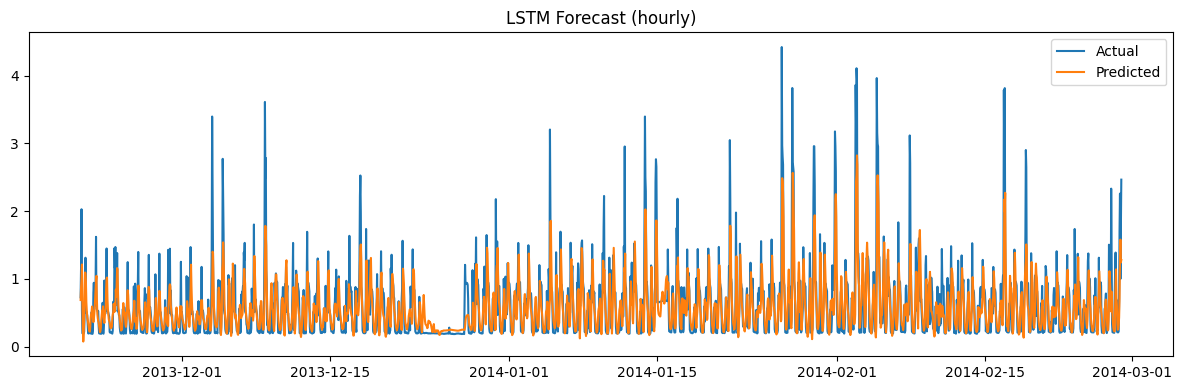

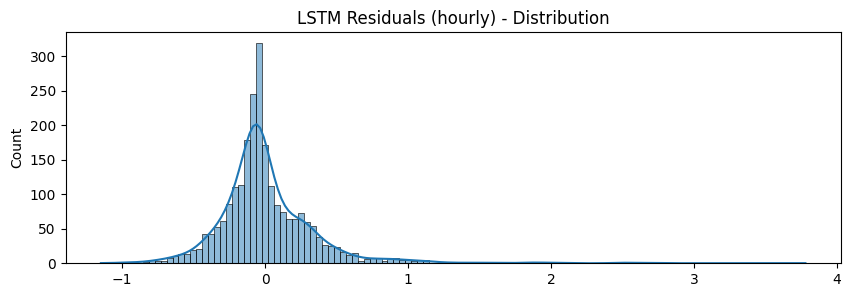

<Figure size 1000x300 with 0 Axes>

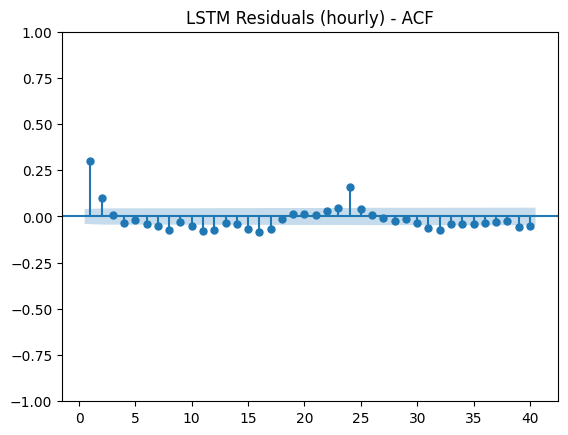

In [49]:
plot_forecast(idx_pred, y_test_inv, y_pred, title=f"LSTM Forecast ({series_choice})")
residuals = y_test_inv - y_pred
residual_diagnostics(residuals, title=f"LSTM Residuals ({series_choice})")

=============================================================================================================

### XGBoost–LSTM hybrid

(LSTM predicts and its preds used as XGB feature)

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [57]:
series_choice = 'hourly'   # or 'daily'
window = 48 if series_choice == 'hourly' else 30

series = df_hourly['energy'] if series_choice == 'hourly' else df_daily['energy']

scaler = MinMaxScaler()
scaled = scaler.fit_transform(series.values.reshape(-1, 1))

In [58]:
train_size = int(len(scaled) * 0.8)
train_scaled = scaled[:train_size]
test_scaled  = scaled[train_size:]

In [59]:
# full sequences for continuity between train and test
full_scaled = np.concatenate([train_scaled, test_scaled])
X_seq, y_seq = create_sequences(full_scaled.flatten(), window)

In [60]:
# splitting into train/test parts
split_idx = len(train_scaled) - window
X_tr_seq, y_tr_seq = X_seq[:split_idx], y_seq[:split_idx]
X_te_seq, y_te_seq = X_seq[split_idx:], y_seq[split_idx:]

In [61]:
# Reshape for LSTM
X_tr = X_tr_seq.reshape((X_tr_seq.shape[0], X_tr_seq.shape[1], 1))
X_te = X_te_seq.reshape((X_te_seq.shape[0], X_te_seq.shape[1], 1))

print(f"Train samples: {X_tr.shape}, Test samples: {X_te.shape}")

Train samples: (9609, 48, 1), Test samples: (2415, 48, 1)


In [62]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_tr, y_tr_seq, validation_split=0.1, epochs=10, batch_size=64,
                    callbacks=[es], verbose=1)

Epoch 1/10
136/136 [==============================] - 5s 22ms/step - loss: 0.0073 - val_loss: 0.0110
Epoch 2/10
136/136 [==============================] - 3s 21ms/step - loss: 0.0063 - val_loss: 0.0098
Epoch 3/10
136/136 [==============================] - 3s 22ms/step - loss: 0.0058 - val_loss: 0.0095
Epoch 4/10
136/136 [==============================] - 3s 20ms/step - loss: 0.0055 - val_loss: 0.0085
Epoch 5/10
136/136 [==============================] - 3s 20ms/step - loss: 0.0052 - val_loss: 0.0080
Epoch 6/10
136/136 [==============================] - 3s 22ms/step - loss: 0.0052 - val_loss: 0.0080
Epoch 7/10
136/136 [==============================] - 3s 23ms/step - loss: 0.0050 - val_loss: 0.0077
Epoch 8/10
136/136 [==============================] - 3s 21ms/step - loss: 0.0050 - val_loss: 0.0076
Epoch 9/10
136/136 [==============================] - 3s 20ms/step - loss: 0.0050 - val_loss: 0.0077
Epoch 10/10
136/136 [==============================] - 3s 22ms/step - loss: 0.0049 - val_lo

In [63]:
# LSTM predictions
lstm_train_pred = model.predict(X_tr)
lstm_test_pred = model.predict(X_te)

76/76 [==============================] - 0s 6ms/step


In [64]:
# Inverse scale
lstm_train_pred_rescaled = scaler.inverse_transform(lstm_train_pred)
lstm_test_pred_rescaled = scaler.inverse_transform(lstm_test_pred)
y_tr_rescaled = scaler.inverse_transform(y_tr_seq.reshape(-1,1))
y_te_rescaled = scaler.inverse_transform(y_te_seq.reshape(-1,1))

In [65]:
# Train XGBoost on LSTM predictions + past lags

# lag features
lags = 5
def make_lag_features(data, lags):
    df_feat = pd.DataFrame(data, columns=['energy'])
    for i in range(1, lags + 1):
        df_feat[f'lag_{i}'] = df_feat['energy'].shift(i)
    df_feat.dropna(inplace=True)
    return df_feat

In [66]:
# train portion for fitting
train_feats = make_lag_features(lstm_train_pred.flatten(), lags)
test_feats = make_lag_features(
    np.concatenate([lstm_train_pred.flatten()[-lags:], lstm_test_pred.flatten()]), lags
)

In [67]:
# Align targets
y_train_xgb = y_tr_rescaled[-len(train_feats):].flatten()
y_test_xgb = y_te_rescaled[-len(test_feats):].flatten()

In [68]:
# training XGBoost regressor
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5)
xgb_model.fit(train_feats, y_train_xgb)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [69]:
# XGBoost predictions (final hybrid output)
xgb_train_pred = xgb_model.predict(train_feats)
xgb_test_pred = xgb_model.predict(test_feats)

In [71]:
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return float(mse), float(rmse), float(mae), float(mape), float(r2)

In [72]:
# Model Performance
mse, rmse, mae, mape, r2 = evaluate(y_test_xgb, xgb_test_pred)

print(f"\n==== {series_choice.upper()} HYBRID XGBOOST–LSTM RESULTS ====")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE (%): {mape:.2f}")
print(f"R²: {r2:.4f}")


==== HOURLY HYBRID XGBOOST–LSTM RESULTS ====
MSE: 0.1310
RMSE: 0.3619
MAE: 0.2205
MAPE (%): 43.44
R²: 0.5018


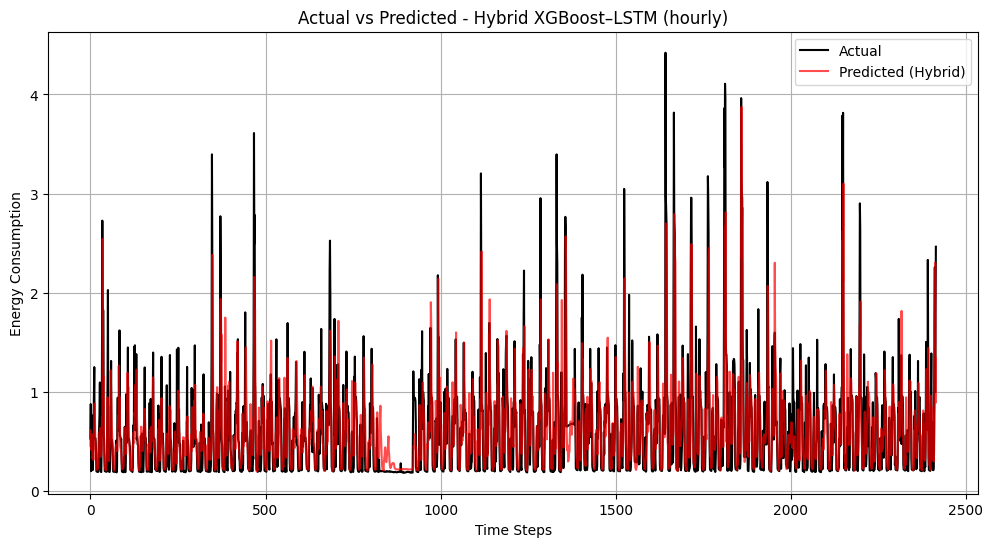

In [73]:
#Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(y_test_xgb, label='Actual', color='black')
plt.plot(xgb_test_pred, label='Predicted (Hybrid)', color='red', alpha=0.7)
plt.title(f"Actual vs Predicted - Hybrid XGBoost–LSTM ({series_choice})")
plt.xlabel("Time Steps")
plt.ylabel("Energy Consumption")
plt.legend()
plt.grid(True)
plt.show()

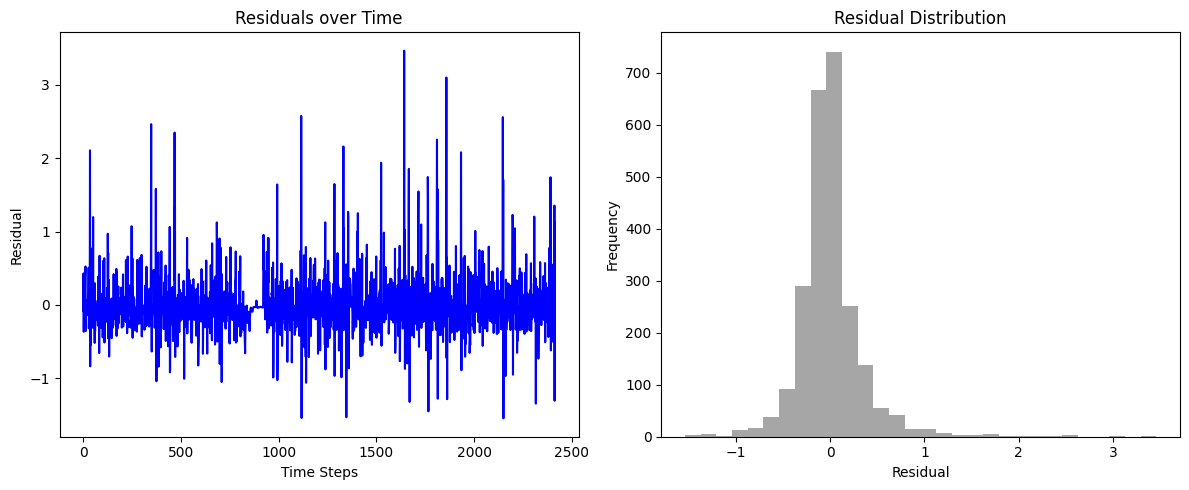

In [74]:
# Residual Diagnostics
residuals = y_test_xgb - xgb_test_pred

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(residuals, color='blue')
plt.title("Residuals over Time")
plt.xlabel("Time Steps")
plt.ylabel("Residual")

plt.subplot(1,2,2)
plt.hist(residuals, bins=30, color='gray', alpha=0.7)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

=============================================================================================================

### ARIMA–XGBoost

(residual modeling)

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
from xgboost import XGBRegressor
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

In [77]:
series_choice = 'hourly'  # 'hourly' or 'daily'
series = df_hourly['energy']
# Train-test split (80-20)
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]
print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 9657, Test size: 2415


In [78]:
# ARIMA on train
auto_model = auto_arima(
    train,
    seasonal=False,  # set True if you have strong weekly/seasonal patterns
    trace=True,
    stepwise=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\nBest ARIMA order: {auto_model.order}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=6233.640, Time=5.54 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8556.654, Time=0.35 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7822.095, Time=0.64 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7564.318, Time=0.42 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8554.654, Time=0.15 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=6214.020, Time=3.75 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=7142.861, Time=3.64 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6244.738, Time=2.13 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=6198.865, Time=5.85 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=6524.169, Time=3.60 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=6210.072, Time=6.47 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=6228.297, Time=6.02 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=6258.990, Time=5.91 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=6185.707, Time=7.01 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept

In [79]:
# predict ARIMA on both train and test
arima_train_pred = auto_model.predict_in_sample()
arima_test_pred = auto_model.predict(n_periods=len(test))

In [80]:
# Residuals
residuals = train - arima_train_pred
future_features = np.arange(len(residuals), len(residuals) + len(test)).reshape(-1, 1)

In [81]:
# training XGBoost on Residuals
print("\n>>> Training XGBoost on residuals...")
X_train = np.arange(len(residuals)).reshape(-1, 1)
y_train = residuals.values

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)


>>> Training XGBoost on residuals...


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [82]:
# predict residual correction
xgb_resid_pred = xgb_model.predict(future_features)

In [84]:
# Combine ARIMA + XGBoost Predictions
hybrid_pred = arima_test_pred + xgb_resid_pred

In [85]:
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, mape, r2

In [86]:
mse, rmse, mae, mape, r2 = evaluate(test, hybrid_pred)

print(f"\n==== {series_choice.upper()} HYBRID ARIMA–XGBOOST RESULTS ====")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE (%): {mape:.2f}")
print(f"R²: {r2:.4f}")


==== HOURLY HYBRID ARIMA–XGBOOST RESULTS ====
MSE: 0.3026
RMSE: 0.5501
MAE: 0.3485
MAPE (%): 60.83
R²: -0.1509


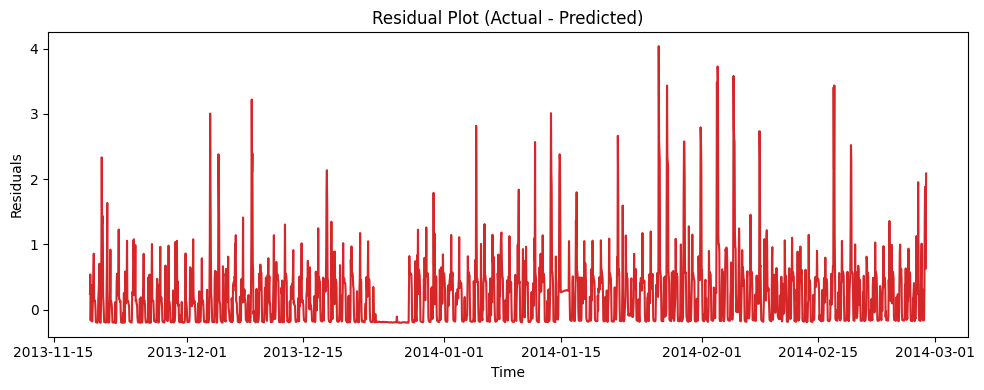

In [87]:
plt.figure(figsize=(10,4))
plt.plot(test.index, test - hybrid_pred, color='tab:red')
plt.title('Residual Plot (Actual - Predicted)')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

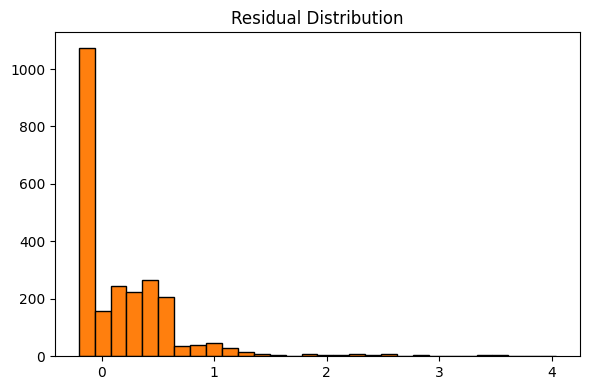

In [88]:
plt.figure(figsize=(6,4))
plt.hist(test - hybrid_pred, bins=30, color='tab:orange', edgecolor='black')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

=============================================================================================================

### ARIMA–LSTM

(residual modeling)

In [89]:
# ARIMA-LSTM hybrid
series_choice = 'hourly'  # 'hourly' or 'daily'
series = df_hourly['energy']
# Train-test split (80-20)
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]
print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 9657, Test size: 2415


In [90]:
# ARIMA fit
auto_model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    stepwise=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\nBest ARIMA order: {auto_model.order}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=6233.640, Time=5.28 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8556.654, Time=0.35 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7822.095, Time=0.70 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7564.318, Time=0.38 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8554.654, Time=0.14 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=6214.020, Time=3.35 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=7142.861, Time=3.14 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6244.738, Time=1.85 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=6198.865, Time=5.60 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=6524.169, Time=3.82 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=6210.072, Time=6.73 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=6228.297, Time=5.80 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=6258.990, Time=5.90 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=6185.707, Time=7.37 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept

In [91]:
# predict ARIMA on both train and test
arima_train_pred = auto_model.predict_in_sample()
arima_test_pred = auto_model.predict(n_periods=len(test))

In [92]:
# Residuals
residuals = train - arima_train_pred
residuals = residuals.to_frame(name="residual")

In [93]:
# data for lstm
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

In [94]:
# Scale residuals
scaler = MinMaxScaler()
res_scaled = scaler.fit_transform(residuals)

In [95]:
# LSTM sequences
window = 24 if series_choice == 'hourly' else 7
X, y = create_sequences(res_scaled.flatten(), window)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [96]:
# Reshape for LSTM (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [97]:
# training LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [98]:
print("\n>>> Training LSTM on ARIMA residuals...")
model.fit(X_train, y_train, validation_split=0.1, epochs=15, batch_size=64, callbacks=[es], verbose=1)


>>> Training LSTM on ARIMA residuals...
Epoch 1/15
109/109 [==============================] - 4s 15ms/step - loss: 0.0079 - val_loss: 0.0021
Epoch 2/15
109/109 [==============================] - 1s 11ms/step - loss: 0.0043 - val_loss: 0.0022
Epoch 3/15
109/109 [==============================] - 1s 12ms/step - loss: 0.0043 - val_loss: 0.0025
Epoch 4/15
109/109 [==============================] - 1s 13ms/step - loss: 0.0043 - val_loss: 0.0022
Epoch 5/15
109/109 [==============================] - 1s 12ms/step - loss: 0.0042 - val_loss: 0.0023
Epoch 6/15
109/109 [==============================] - 1s 12ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 7/15
109/109 [==============================] - 1s 13ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 8/15
109/109 [==============================] - 1s 13ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 9/15
109/109 [==============================] - 1s 11ms/step - loss: 0.0042 - val_loss: 0.0022
Epoch 10/15
109/109 [=============================

In [99]:
# Predict residuals using LSTM
lstm_pred_resid = model.predict(X_test)
lstm_pred_resid = scaler.inverse_transform(lstm_pred_resid)

61/61 [==============================] - 1s 3ms/step


In [100]:
# Align lengths with test set
final_resid_pred = pd.Series(lstm_pred_resid.flatten(), index=test.index[-len(lstm_pred_resid):])

In [101]:
# Combine ARIMA + LSTM Predictions
hybrid_pred = arima_test_pred[-len(final_resid_pred):] + final_resid_pred.values

In [102]:
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, mape, r2


In [103]:
mse, rmse, mae, mape, r2 = evaluate(test[-len(hybrid_pred):], hybrid_pred)

print(f"\n==== {series_choice.upper()} HYBRID ARIMA–LSTM RESULTS ====")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE (%): {mape:.2f}")
print(f"R²: {r2:.4f}")


==== HOURLY HYBRID ARIMA–LSTM RESULTS ====
MSE: 0.3170
RMSE: 0.5630
MAE: 0.3624
MAPE (%): 63.04
R²: -0.1526


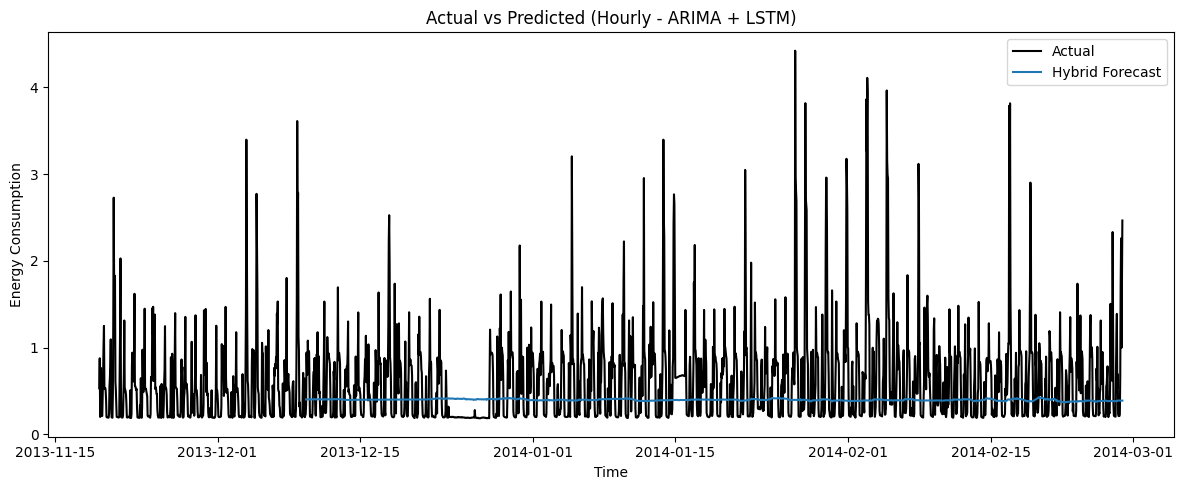

In [104]:
# actual vs pred
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Actual', color='black')
plt.plot(test.index[-len(hybrid_pred):], hybrid_pred, label='Hybrid Forecast', color='tab:blue')
plt.title(f'Actual vs Predicted ({series_choice.capitalize()} - ARIMA + LSTM)')
plt.xlabel('Time')
plt.ylabel('Energy Consumption')
plt.legend()
plt.tight_layout()
plt.show()

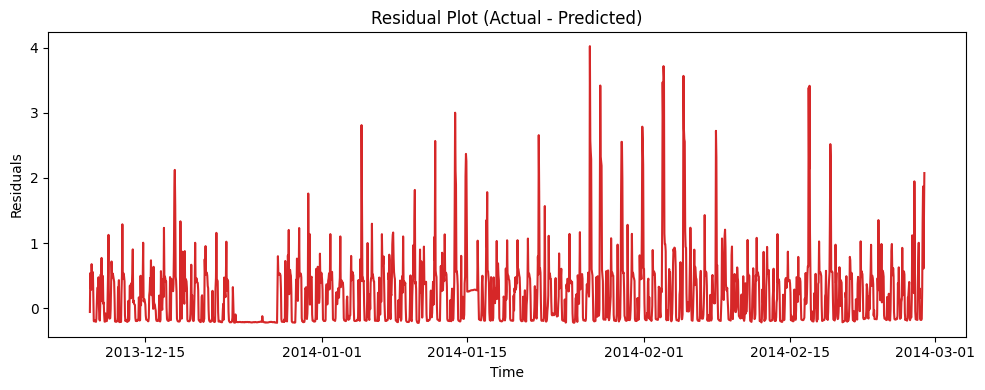

In [105]:
plt.figure(figsize=(10,4))
plt.plot(test.index[-len(hybrid_pred):], test[-len(hybrid_pred):] - hybrid_pred, color='tab:red')
plt.title('Residual Plot (Actual - Predicted)')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

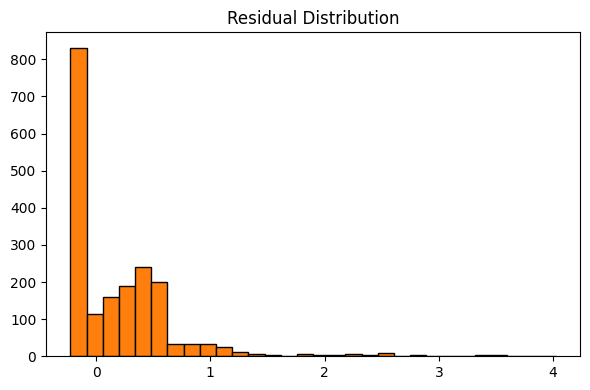

In [106]:
plt.figure(figsize=(6,4))
plt.hist(test[-len(hybrid_pred):] - hybrid_pred, bins=30, color='tab:orange', edgecolor='black')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

=============================================================================================================

| Model                    |    MSE |   RMSE |        MAE |  MAPE (%) |        R² | Interpretation                                                                     |
| :----------------------- | -----: | -----: | ---------: | --------: | --------: | :--------------------------------------------------------------------------------- |
| **ARIMA**                | 0.2645 | 0.5143 |     0.3526 |     86.20 |    -0.006 | Poor – fails to capture nonlinear and high-frequency variations.                   |
| **Prophet**              | 0.2423 | 0.4922 |     0.3851 |    118.63 |     0.079 | Slight improvement in R² but unstable; Prophet struggles with high-frequency data. |
| **XGBoost**              | 0.1056 | 0.3249 |     0.1855 |     35.68 | **0.600** | Best performance – effectively captures nonlinear temporal dependencies.           |
| **LSTM**                 | 0.1306 | 0.3614 |     0.2274 |     46.04 |     0.502 | Strong learner – learns temporal patterns but less robust than XGBoost.            |
| **Hybrid XGBoost–LSTM**  | 0.1310 | 0.3619 | **0.2205** | **43.44** |     0.502 | Very close to standalone LSTM – minor improvement in bias correction.              |
| **Hybrid ARIMA–XGBoost** | 0.3026 | 0.5501 |     0.3485 |     60.83 |    -0.151 | Weak hybrid – ARIMA adds little value; noise dominates residual learning.          |
| **Hybrid ARIMA–LSTM**    | 0.3170 | 0.5630 |     0.3624 |     63.04 |    -0.153 | Similar to ARIMA–XGBoost; ARIMA residuals too erratic for LSTM learning.           |


XGBoost: Clearly the best performer — lowest overall error and highest R², showing strong ability to learn nonlinear and short-term consumption dynamics.

LSTM: Performs slightly worse but comparable — captures temporal structure well, though more sensitive to noise and data scaling.

Hybrid XGBoost–LSTM: Only marginally improves MAE and MAPE — suggests both models already learn similar nonlinear signals, leaving little residual correction value.

ARIMA & Prophet: Both fail on high-frequency (hourly) data — linear and additive assumptions cannot handle the volatility of consumption patterns.

Hybrid ARIMA–XGBoost / ARIMA–LSTM: Underperform — ARIMA residuals are mostly noise; combining with nonlinear learners amplifies variance instead of reducing error.

=============================================================================================================

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = [
    ['ARIMA', 0.5143, 0.3526, -0.006],
    ['Prophet', 0.4922, 0.3851, 0.079],
    ['XGBoost', 0.3249, 0.1855, 0.600],
    ['LSTM', 0.3614, 0.2274, 0.502],
    ['Hybrid XGBoost–LSTM', 0.3619, 0.2205, 0.502],
    ['Hybrid ARIMA–XGBoost', 0.5501, 0.3485, -0.151],
    ['Hybrid ARIMA–LSTM', 0.5630, 0.3624, -0.153]
]

df_metrics = pd.DataFrame(data, columns=['Model', 'RMSE', 'MAE', 'R²'])

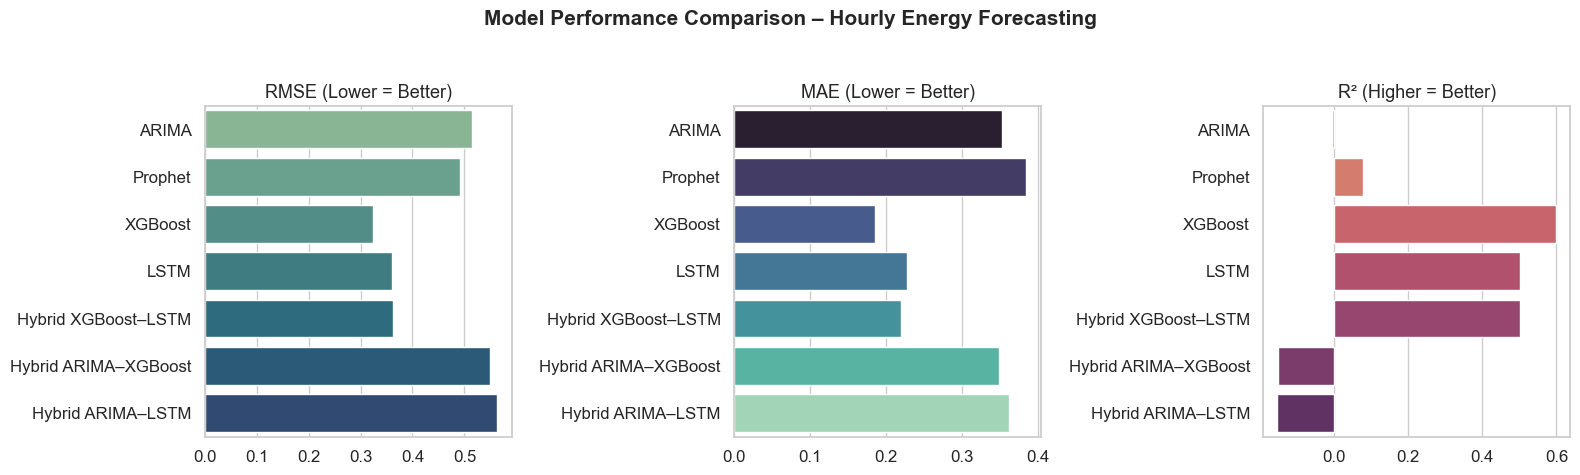

In [108]:
# Plot Styling
sns.set(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- RMSE ---
sns.barplot(ax=axes[0], x='RMSE', y='Model', data=df_metrics, palette='crest')
axes[0].set_title('RMSE (Lower = Better)', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# --- MAE ---
sns.barplot(ax=axes[1], x='MAE', y='Model', data=df_metrics, palette='mako')
axes[1].set_title('MAE (Lower = Better)', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# --- R² ---
sns.barplot(ax=axes[2], x='R²', y='Model', data=df_metrics, palette='flare')
axes[2].set_title('R² (Higher = Better)', fontsize=13)
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.suptitle('Model Performance Comparison – Hourly Energy Forecasting', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

=============================================================================================================